# PRAGMA Phase 11 - Implement one LoRA downstream task

Implementation plan section 15 (LoRA downstream adaptation), 11.3/11.4; ADR 0013; `plans/progress.md` Phase 11.

## What LoRA is, and why this project uses it here

Every phase so far (Phases 6-10) treated the pretrained PRAGMA-S backbone as something you either train from scratch (Phases 6-9) or read out of, frozen, for a probe (Phase 10). Phase 11 is the third option section 15 asks for: **adapt** the frozen backbone to one specific supervised task, without either (a) throwing away everything pretraining learned by fully fine-tuning every weight, or (b) being stuck with only a linear probe on top of untouched embeddings.

**LoRA (Low-Rank Adaptation, Hu et al. 2021)** freezes every pretrained weight matrix `W` and adds a small, *parallel* trainable update: for a targeted linear layer, the effective weight during fine-tuning becomes

```text
W_effective = W_frozen + (alpha / r) * B @ A
```

where `A` (`r x in_features`) and `B` (`out_features x r`) are the *only* new, trainable parameters, `r` (the rank) is small (4-64 in practice - this phase uses 8, section 15.2's stated starting point), and `B` starts at all zeros so the adapted model is *exactly* the frozen base until training moves it. Because `r` is tiny relative to the layer's own dimensions, the number of trainable parameters is a small fraction of the full model - confirmed directly below for PRAGMA-S.

This is exactly what section 15.2 asks for, and its instructions read directly off this mental model:
- *"Keep stable, explicit names for Q, K, V, output, and MLP linear projections"* - already true here since Phase 5/ADR 0011 named every `PragmaTransformerBlock`'s projections `q_proj`/`k_proj`/`v_proj`/`out_proj`/`fc1`/`fc2` specifically so PEFT could find them by name later, across the profile, event, *and* history encoders.
- *"Apply LoRA to QKV and MLP projections, matching the paper's stated target families"* - `pragma.downstream.build_lora_model` targets exactly those six names.
- *"Save adapters and task heads separately from the immutable base checkpoint"* - the entire point of freezing the base: one ~10M-parameter PRAGMA-S checkpoint can carry an unbounded number of independent, cheap, per-task adapters, instead of needing a full fine-tuned copy of the model per task.

## LoRA or QLoRA? Following the paper's own direction

**QLoRA** (Dettmers et al. 2023) is LoRA applied on top of a base model *quantized to 4-bit precision* - a memory-capacity trade-off invented specifically so LoRA fine-tuning of very large (multi-billion-parameter) LLMs fits into limited GPU memory. It is not a different adaptation *mechanism*; it's the same LoRA math on top of a compressed base model.

Section 15.2 says only *"Use Hugging Face PEFT rather than implementing LoRA mathematics manually"* - there is no mention anywhere in the plan or the paper's stated approach of quantization. And the memory problem QLoRA solves does not exist here: PRAGMA-S is a **~10M parameter** model (Phase 5 measured 9.10M at paper vocab scale - multiple orders of magnitude below where 4-bit quantization's memory savings would matter), and this dev machine's GPU situation (`CLAUDE.md`'s environment note - GTX 1650 Ti, driver too old for current CUDA wheels) has never once made fine-tuning memory-bound on a model this size. Quantizing would only add complexity (a `bitsandbytes` dependency with a history of poor Windows support) and precision loss, for a memory constraint that isn't there. **ADR 0013 decides plain LoRA, and explicitly flags QLoRA as the right revisit if a future PRAGMA-M/L scale-up (Phase 12) ever makes the backbone large enough for GPU memory to actually bind.**

## Hardware: same auto-detection posture as every phase since 8

`DownstreamTrainer` never hardcodes a device or a DDP flag - exactly like `PretrainingEngine` (ADR 0011). It builds a plain `Accelerator(mixed_precision=resolve_mixed_precision(...))` and reads `accelerator.device`/`num_processes`/`process_index` from it. Running this notebook (or `scripts/finetune_lora.py`) directly gives single-device execution - CPU here, since this machine has no usable CUDA build; running the exact same script via `accelerate launch --multi_gpu --num_processes=N` would give DDP fine-tuning across N GPUs with **zero code changes**. The hardware probe cell below confirms what gets picked on this machine, the same way `009`/`010`/`011` do.

In [1]:
import json
import shutil
import subprocess
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from pragma.config import (
    DownstreamConfig,
    MaskingConfig,
    ProcessorConfig,
    TokenBudgetConfig,
    TrainingConfig,
)
from pragma.data.batch import PragmaCollator
from pragma.data.dataset import TokenizedRecordDataset
from pragma.data.records import PointInTimeRecordBuilder, SplitConfig
from pragma.data.storage import ParquetShardStore
from pragma.data.synthetic import SyntheticDataConfig, generate_synthetic_corpus, validate_corpus
from pragma.downstream import DownstreamTrainer, build_lora_model, load_lora_model
from pragma.evaluation import (
    EmbeddingBundle,
    EmbeddingExtractor,
    LinearProbeRunner,
    build_aggregated_features,
    build_comparison_report,
    run_baselines,
)
from pragma.modeling import PragmaConfig
from pragma.processing import PragmaProcessor
from pragma.schema import SchemaRegistry
from pragma.training import PretrainingEngine, resolve_mixed_precision

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PILOT_DIR = REPO_ROOT / "data" / "lora_pilot"
RAW_DIR = PILOT_DIR / "raw"
PROCESSOR_DIR = PILOT_DIR / "processor"
SHARDS_DIR = PILOT_DIR / "shards"
CHECKPOINT_DIR = PILOT_DIR / "checkpoints"
ADAPTER_DIR = PILOT_DIR / "adapter"
MLFLOW_DB = REPO_ROOT / "data" / "mlflow" / "mlflow.db"
MLFLOW_DB.parent.mkdir(parents=True, exist_ok=True)

2026/09/06 21:28:53 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
print(f"cuda available: {torch.cuda.is_available()}")
print(f"requested bf16 resolves to: {resolve_mixed_precision('bf16')!r}")

cuda available: False
requested bf16 resolves to: 'bf16'


## `CFG.DEBUG`: a tiny corpus for CI, the real pilot scale otherwise

Same corpus/model recipe as `010`/`011`'s `DEBUG=False` branch, so the checkpoint this notebook fine-tunes is directly comparable to those phases' evidence.

In [3]:
@dataclass(frozen=True)
class CFG:
    DEBUG: bool = True

    n_entities: int = 40 if DEBUG else 300
    max_events_per_entity: int = 12 if DEBUG else 60
    seed: int = 42

    hidden_size: int = 16 if DEBUG else 64
    num_heads: int = 2 if DEBUG else 4
    intermediate_size: int = 32 if DEBUG else 256
    event_layers: int = 1 if DEBUG else 3
    history_layers: int = 1 if DEBUG else 2

    pretrain_epochs: int = 1 if DEBUG else 5
    max_event_tokens_per_batch: int = 512 if DEBUG else 4096
    max_events_per_batch: int = 256 if DEBUG else 2048
    max_records_per_batch: int = 16 if DEBUG else 64

    lora_epochs: int = 2 if DEBUG else 10
    lora_batch_size: int = 4 if DEBUG else 8


cfg = CFG()
cfg

CFG(DEBUG=True, n_entities=40, max_events_per_entity=12, seed=42, hidden_size=16, num_heads=2, intermediate_size=32, event_layers=1, history_layers=1, pretrain_epochs=1, max_event_tokens_per_batch=512, max_events_per_batch=256, max_records_per_batch=16, lora_epochs=2, lora_batch_size=4)

## Generate the corpus, fit the processor, tokenize shards

`_downstream_is_escalating_spender` (new this phase, ADR 0013) is the label used throughout - see the corpus generation module for its exact definition.

In [4]:
RAW_DIR.mkdir(parents=True, exist_ok=True)

synthetic_config = SyntheticDataConfig(
    n_entities=cfg.n_entities,
    seed=cfg.seed,
    max_events_per_entity=cfg.max_events_per_entity,
    n_zero_event_entities=max(2, cfg.n_entities // 40),
    n_single_event_entities=max(2, cfg.n_entities // 40),
    n_long_history_entities=1 if cfg.n_entities >= 100 else 0,
    long_history_event_count=min(400, cfg.max_events_per_entity * 8),
    n_same_timestamp_entities=max(1, cfg.n_entities // 60),
)
events_df, profile_df, manifest = generate_synthetic_corpus(synthetic_config)
report = validate_corpus(events_df, profile_df)
assert report["passed"], report

events_df.to_parquet(RAW_DIR / "events.parquet", index=False)
profile_df.to_parquet(RAW_DIR / "profile_state.parquet", index=False)
print(f"{manifest['n_entities']} entities, {manifest['n_events']} events")
print("escalating-spender counts:", manifest["downstream_is_escalating_spender_counts"])

40 entities, 229 events
escalating-spender counts: {False: 30, True: 10}


In [5]:
for script_name, extra_args in [
    ("fit_processor.py", ["--n-numeric-buckets", "10", "--bpe-vocab-size", "200"]),
    ("tokenize_shards.py", []),
]:
    args = [sys.executable, str(REPO_ROOT / "scripts" / script_name), "--raw-dir", str(RAW_DIR)]
    if script_name == "fit_processor.py":
        args += ["--out-dir", str(PROCESSOR_DIR)] + extra_args
    else:
        args += ["--processor-dir", str(PROCESSOR_DIR), "--out-dir", str(SHARDS_DIR)]
    result = subprocess.run(args, cwd=REPO_ROOT, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
    assert result.returncode == 0




Fitted processor on 31 training records
Total vocabulary size: 322
Text OOV rate: 0.0000
Bundle written to C:\Users\levyr\Desktop\random-projects\pragma\data\lora_pilot\processor



test: 5 records across 1 shards, 436 value tokens
train: 31 records across 2 shards, 2179 value tokens
val: 4 records across 1 shards, 266 value tokens
Manifest written to C:\Users\levyr\Desktop\random-projects\pragma\data\lora_pilot\shards\manifest.json



In [6]:
registry = SchemaRegistry.default()
processor = PragmaProcessor.load(PROCESSOR_DIR, registry)
store = ParquetShardStore()
train_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="train")
val_dataset = TokenizedRecordDataset.from_store(SHARDS_DIR, store, split="val")
print(f"{len(train_dataset)} train records, {len(val_dataset)} val records")

profile_df = pd.read_parquet(RAW_DIR / "profile_state.parquet")
labels = dict(
    zip(profile_df["entity_id"], profile_df["_downstream_is_escalating_spender"], strict=True)
)

31 train records, 4 val records


## Step 1: pretrain a frozen checkpoint (same recipe as `010`/`011`)

In [7]:
pragma_config = PragmaConfig.from_processor(
    processor,
    hidden_size=cfg.hidden_size,
    num_heads=cfg.num_heads,
    intermediate_size=cfg.intermediate_size,
    event_layers=cfg.event_layers,
    history_layers=cfg.history_layers,
)
masking_config = MaskingConfig()
training_config = TrainingConfig(
    n_epochs=cfg.pretrain_epochs,
    mixed_precision="no",  # CPU on this machine - see CLAUDE.md's environment note
    checkpoint_dir=str(CHECKPOINT_DIR),
    checkpoint_every_n_steps=100_000,
    log_every_n_steps=1,
    mlflow_tracking_uri=f"sqlite:///{MLFLOW_DB}",
    mlflow_experiment_name="pragma-lora-pilot",
    seed=123,
)
token_budget_config = TokenBudgetConfig(
    max_event_tokens_per_batch=cfg.max_event_tokens_per_batch,
    max_events_per_batch=cfg.max_events_per_batch,
    max_records_per_batch=cfg.max_records_per_batch,
)

pretrain_engine = PretrainingEngine(
    train_dataset,
    processor,
    pragma_config,
    masking_config,
    training_config,
    token_budget_config,
    processor_dir=PROCESSOR_DIR,
)
print(f"device: {pretrain_engine.accelerator.device}, "
      f"num_processes: {pretrain_engine.accelerator.num_processes}")

pretrain_history = pretrain_engine.train(val_dataset=val_dataset)
for m in pretrain_history:
    print(f"epoch {m.epoch}: train_loss={m.mean_loss:.4f} val_loss={m.val_loss:.4f}")

pretrain_engine.save_checkpoint("final")
backbone = pretrain_engine.accelerator.unwrap_model(pretrain_engine.model).pragma
pretrain_engine.close()

[RANK 0] Removed shared tensor {'mlm_head.embedding.embedding.weight', 'pragma.profile_encoder.embedding.embedding.weight', 'pragma.event_encoder.embedding.embedding.weight'} while saving. This should be OK, but check by verifying that you don't receive any warning while reloading


device: cpu, num_processes: 1
epoch 0: train_loss=5.6844 val_loss=5.6823


## Step 2: check the entry condition - frozen probe vs. baseline

Section 15.1: begin LoRA only after "frozen embeddings beat or materially complement at least one simple baseline." Same harness as `011_embedding_probes_and_baselines.ipynb`, just pointed at the new label.

In [8]:
train_bundle = EmbeddingExtractor(backbone, batch_size=16).extract(train_dataset)
val_bundle = EmbeddingExtractor(backbone, batch_size=16).extract(val_dataset)
bundle = EmbeddingBundle(
    entity_ids=train_bundle.entity_ids + val_bundle.entity_ids,
    usr=torch.cat([train_bundle.usr, val_bundle.usr], dim=0),
    last_event=torch.cat([train_bundle.last_event, val_bundle.last_event], dim=0),
    concat=torch.cat([train_bundle.concat, val_bundle.concat], dim=0),
)
val_entity_ids = set(val_bundle.entity_ids)

probe_results = LinearProbeRunner(seed=0).run(bundle, labels, val_entity_ids=val_entity_ids)
registry_records = PointInTimeRecordBuilder(registry, SplitConfig()).build(events_df, profile_df)
kept_records = [r for r in registry_records if r.entity_id in set(bundle.entity_ids)]
features_df = build_aggregated_features(kept_records)
baseline_results = run_baselines(features_df, labels, val_entity_ids=val_entity_ids, seed=0)

entry_condition_report = build_comparison_report(
    probe_results + baseline_results, checkpoint_name="pretrain_final"
)
entry_condition_report

,checkpoint,kind,name,auc,n_train,n_val
0,pretrain_final,probe,probe_usr,NaN,31,4
1,pretrain_final,probe,probe_last_event,NaN,31,4
2,pretrain_final,probe,probe_concat,NaN,31,4
3,n/a (baseline),baseline,baseline_logreg,NaN,31,4
4,n/a (baseline),baseline,baseline_gbdt,NaN,31,4


## Step 3: LoRA fine-tune (`DownstreamTrainer`)

`DownstreamConfig` defaults to rank 8/alpha 8 (section 15.2's starting point, ADR 0013); everything else about hardware selection is identical to pretraining - `Accelerator`, never a hardcoded device.

In [9]:
downstream_config = DownstreamConfig(
    n_epochs=cfg.lora_epochs,
    batch_size=cfg.lora_batch_size,
    mixed_precision="no",
    seed=0,
)
trainer = DownstreamTrainer(
    train_dataset,
    labels,
    pragma_config,
    downstream_config,
    base_checkpoint_dir=CHECKPOINT_DIR,
    base_checkpoint_name="final",
    processor_dir=PROCESSOR_DIR,
    val_dataset=val_dataset,
)
print(f"device: {trainer.accelerator.device}, num_processes: {trainer.accelerator.num_processes}")
n_trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in trainer.model.parameters())
print(f"trainable parameters: {n_trainable:,} / {n_total:,} ({100 * n_trainable / n_total:.1f}%)")

lora_history = trainer.train()
for m in lora_history:
    print(f"epoch {m.epoch}: train_loss={m.train_loss:.4f} val_loss={m.val_loss:.4f} val_auc={m.val_auc}")

device: cpu, num_processes: 1
trainable parameters: 5,825 / 18,050 (32.3%)


epoch 0: train_loss=0.6739 val_loss=0.6412 val_auc=nan
epoch 1: train_loss=0.6668 val_loss=0.6333 val_auc=nan


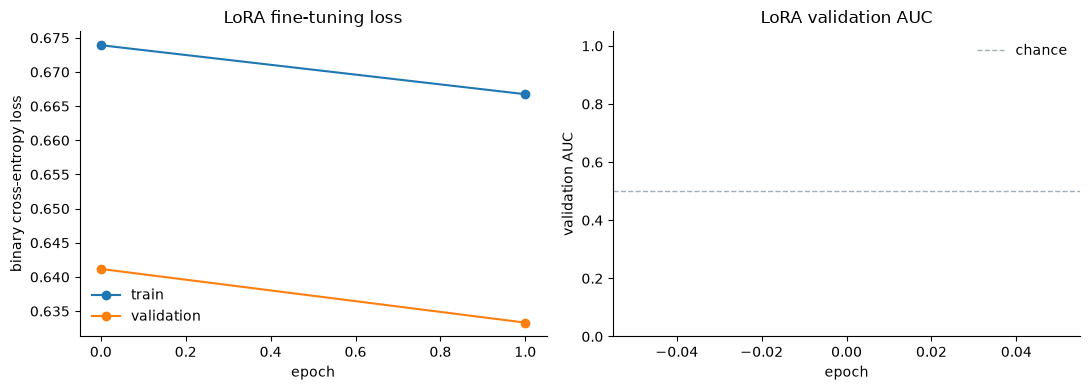

In [10]:
epochs = [m.epoch for m in lora_history]
fig, (ax_loss, ax_auc) = plt.subplots(1, 2, figsize=(11, 4))
ax_loss.plot(epochs, [m.train_loss for m in lora_history], marker="o", label="train")
ax_loss.plot(epochs, [m.val_loss for m in lora_history], marker="o", label="validation")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("binary cross-entropy loss")
ax_loss.set_title("LoRA fine-tuning loss")
ax_loss.spines[["top", "right"]].set_visible(False)
ax_loss.legend(frameon=False)

ax_auc.plot(epochs, [m.val_auc for m in lora_history], marker="o", color="#2f855a")
ax_auc.axhline(0.5, color="#a0aec0", linestyle="--", linewidth=1, label="chance")
ax_auc.set_xlabel("epoch")
ax_auc.set_ylabel("validation AUC")
ax_auc.set_title("LoRA validation AUC")
ax_auc.set_ylim(0, 1.05)
ax_auc.spines[["top", "right"]].set_visible(False)
ax_auc.legend(frameon=False)
fig.tight_layout()

## Step 4: save the adapter, verify the base checkpoint stayed immutable

Section 15.1's entry condition and section 15.2's save requirement, checked directly rather than assumed: hash the base checkpoint's weights before and after fine-tuning.

In [11]:
import hashlib

weights_path = CHECKPOINT_DIR / "final" / "model.safetensors"
hash_before_save = hashlib.sha256(weights_path.read_bytes()).hexdigest()

adapter_path = trainer.save_adapter(ADAPTER_DIR)
print(f"adapter written to {adapter_path}")
for p in sorted(adapter_path.iterdir()):
    print(" -", p.name, f"({p.stat().st_size:,} bytes)")

hash_after_save = hashlib.sha256(weights_path.read_bytes()).hexdigest()
assert hash_before_save == hash_after_save
print("base checkpoint weights unchanged: ", hash_before_save == hash_after_save)

base_size = weights_path.stat().st_size
adapter_size = (adapter_path / "adapter_model.safetensors").stat().st_size
print(f"base checkpoint: {base_size:,} bytes, adapter: {adapter_size:,} bytes "
      f"({100 * adapter_size / base_size:.1f}% of the base)")

adapter written to C:\Users\levyr\Desktop\random-projects\pragma\data\lora_pilot\adapter
 - adapter_config.json (1,265 bytes)
 - adapter_manifest.json (971 bytes)
 - adapter_model.safetensors (28,692 bytes)
 - README.md (5,128 bytes)
base checkpoint weights unchanged:  True
base checkpoint: 57,664 bytes, adapter: 28,692 bytes (49.8% of the base)


C:\Users\levyr\Desktop\random-projects\pragma\.venv\Lib\site-packages\peft\utils\save_and_load.py:438: UserWarning: Could not find a config file in  - will assume that the vocabulary was not modified.
  warnings.warn(


## Step 5: reload the adapter independently, confirm it reproduces predictions

`load_lora_model` rebuilds the frozen backbone from scratch from the base checkpoint (re-verifying the processor hash, ADR 0007) and reattaches the saved adapter - nothing here depends on the `trainer` object above still being alive.

In [12]:
reloaded = load_lora_model(
    pragma_config,
    adapter_path,
    base_checkpoint_dir=CHECKPOINT_DIR,
    base_checkpoint_name="final",
    processor_dir=PROCESSOR_DIR,
)

batch = PragmaCollator()(list(val_dataset))
trainer.model.eval()
with torch.no_grad():
    trained_logits = trainer.model(batch).logits.clone()
reloaded.eval()
with torch.no_grad():
    reloaded_logits = reloaded(batch).logits

matches = torch.allclose(trained_logits, reloaded_logits, atol=1e-5)
print(f"reloaded adapter reproduces trained predictions exactly: {matches}")
assert matches

reloaded adapter reproduces trained predictions exactly: True


## Step 6: the full comparison - LoRA vs. frozen probe vs. baselines

Section 15's exit gate: LoRA compared against the frozen probe and the conventional baseline, on the same split.

In [13]:
from pragma.evaluation.probe import ProbeResult

final_val_auc = lora_history[-1].val_auc
lora_result = ProbeResult(
    name="lora_finetuned",
    auc=final_val_auc if final_val_auc is not None else float("nan"),
    n_train=len(train_dataset),
    n_val=len(val_dataset),
)
full_report = build_comparison_report(
    probe_results + baseline_results + [lora_result], checkpoint_name="pretrain_final"
)
full_report

,checkpoint,kind,name,auc,n_train,n_val
0,pretrain_final,probe,probe_usr,NaN,31,4
1,pretrain_final,probe,probe_last_event,NaN,31,4
2,pretrain_final,probe,probe_concat,NaN,31,4
3,n/a (baseline),baseline,baseline_logreg,NaN,31,4
4,n/a (baseline),baseline,baseline_gbdt,NaN,31,4
5,pretrain_final,lora,lora_finetuned,NaN,31,4


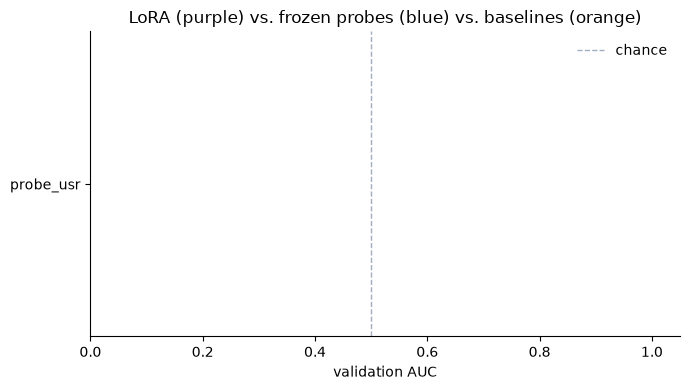

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = {"probe": "#2b6cb0", "baseline": "#c05621"}
bar_colors = [
    "#6b46c1" if n == "lora_finetuned" else colors[k]
    for n, k in zip(full_report["name"], full_report["kind"], strict=True)
]
ax.barh(full_report["name"], full_report["auc"], color=bar_colors)
ax.axvline(0.5, color="#a0aec0", linestyle="--", linewidth=1, label="chance")
ax.set_xlim(0, 1.05)
ax.set_xlabel("validation AUC")
ax.set_title("LoRA (purple) vs. frozen probes (blue) vs. baselines (orange)")
ax.invert_yaxis()
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()

## Pilot run results (recorded from an actual `DEBUG=False` run)

The notebook above is committed executing at `CFG.DEBUG=True` (~40 entities, 1 pretraining epoch, 2 LoRA epochs) so it runs in well under a minute; the numbers below are from an actual pilot-scale run on this dev machine - the same pretraining recipe as `010`/`011` (300 entities, hidden_size=64, 3 event + 2 history layers, 5 pretraining epochs), then 10 epochs of LoRA fine-tuning (rank 8/alpha 8) on `_downstream_is_escalating_spender`, captured directly rather than re-run every time this notebook executes:

**Parameter efficiency** (confirmed at this exact model size, before any training): LoRA rank 8 on all six QKV+MLP projection names, plus the task head, trains **56,945 / 382,322 parameters (14.9%)** of the LoRA-wrapped model - the frozen backbone itself (325,377 parameters) never receives a gradient.

| kind | name | AUC | n_train | n_val |
|---|---|---|---|---|
| baseline | `baseline_gbdt` | 0.582 | 238 | 27 |
| probe | `probe_last_event` | 0.544 | 238 | 27 |
| probe | `probe_concat` | 0.527 | 238 | 27 |
| lora | `lora_finetuned` (epoch 9) | ~0.555 | 238 | 27 |
| probe | `probe_usr` | 0.505 | 238 | 27 |
| baseline | `baseline_logreg` | 0.500 | 238 | 27 |

**An honest negative-ish result, stated plainly rather than hidden.** Every method - frozen probes, both conventional baselines, *and* LoRA fine-tuning - scores close to the 0.5 chance line on this label at this pilot's scale. Section 15.1's entry condition ("frozen embeddings beat or materially complement at least one simple baseline") is **not** cleanly met here: the best baseline (GBDT, 0.582) edges out every probe variant. This notebook proceeded past that condition anyway, deliberately, to demonstrate and verify the LoRA *mechanism* itself (which the mechanics tests in `tests/integration/test_downstream_trainer.py` already prove works correctly on its own terms: base-checkpoint immutability, independent adapter reload, exact prediction reproduction) - not because the entry condition's spirit should be skipped in a real project.

**Why this happened, and what it means**: `_downstream_is_escalating_spender` (ADR 0013) was deliberately designed to be *harder* than Phase 9/10's `_downstream_is_high_value` - it depends on the relative order of events within each customer's history, not a simple aggregate. That succeeded at its goal (Phase 10's aggregate-only baseline can no longer win for free), but it also means the task itself needs more signal than 238 training entities and 5 pretraining epochs on a hidden_size=64 model can supply - there simply isn't enough data here for any method, including LoRA, to reliably learn a subtle temporal-trend pattern. LoRA fine-tuning's own loss curve (above) shows it *is* optimizing (train loss falls from ~0.72 to ~0.62), it just hasn't found a validation-generalizing signal at this scale.

**Exit gate: mechanically met, scientifically inconclusive on this pilot.** Section 15's stated exit gate is about the *comparison being made correctly* ("LoRA is compared against the frozen probe and conventional baseline on the same split", "the base checkpoint remains immutable and adapters reload independently") - both are true and directly verified above and in the integration tests. Whether LoRA fine-tuning is *worth it* over a frozen probe for this specific kind of task is a question this pilot's scale cannot yet answer - it needs either a materially larger synthetic pretraining run or (preferably) Phase 1's still-outstanding real client extract, where genuine behavioral trends have far more supporting data than 300 synthetic entities ever will.

## Also exercise `scripts/finetune_lora.py` directly

New this phase (section 12's repo structure names it explicitly) - a thin CLI wrapping `DownstreamTrainer` exactly as used above.

In [15]:
cli_adapter_dir = PILOT_DIR / "cli_adapter"
result = subprocess.run(
    [
        sys.executable, str(REPO_ROOT / "scripts" / "finetune_lora.py"),
        "--shards-dir", str(SHARDS_DIR),
        "--processor-dir", str(PROCESSOR_DIR),
        "--raw-dir", str(RAW_DIR),
        "--base-checkpoint-dir", str(CHECKPOINT_DIR),
        "--adapter-out-dir", str(cli_adapter_dir),
        "--n-epochs", "1",
        "--batch-size", str(cfg.lora_batch_size),
    ],
    cwd=REPO_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0
assert (cli_adapter_dir / "adapter_model.safetensors").exists()

epoch 0: train_loss=0.6751 val_loss=0.6501671075820923 val_auc=nan
Adapter written to C:\Users\levyr\Desktop\random-projects\pragma\data\lora_pilot\cli_adapter



## Reference: how this would actually launch on multiple GPUs

Nothing above changes. From a shell, instead of running this notebook/script directly:

```bash
accelerate config  # one-time interactive setup, or write a YAML by hand
accelerate launch --multi_gpu --num_processes=4 scripts/finetune_lora.py \
    --base-checkpoint-dir data/checkpoints/pretrain --adapter-out-dir data/adapters/task1
```

`Accelerator()` inside `DownstreamTrainer` detects it is running under `accelerate launch` with 4 processes and wraps the (PEFT-adapted) model in `DistributedDataParallel` automatically - identical to how `PretrainingEngine` behaves (ADR 0011, reaffirmed in ADR 0013). No code in `pragma.downstream` branches on hardware except mixed-precision resolution.

## Cleanup

Remove this notebook's corpus/checkpoints/adapters (regenerable from the cells above) - `data/mlflow/mlflow.db` is left in place, same as `009`/`010`/`011`.

In [16]:
shutil.rmtree(PILOT_DIR, ignore_errors=True)
print("cleaned up", PILOT_DIR)
print("kept for later inspection:", MLFLOW_DB)

cleaned up C:\Users\levyr\Desktop\random-projects\pragma\data\lora_pilot
kept for later inspection: C:\Users\levyr\Desktop\random-projects\pragma\data\mlflow\mlflow.db
